In [6]:
import matplotlib as plt
import platform
import pandas as pd
# 한글 폰트 깨짐 방지 세팅
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
if platform.system() == 'Darwin': # Mac 
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows 사용자
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호 깨짐 방지


---

### <center> 1. 머신 러닝 (XG BOOST 앙상블 모델)

---

🚀 [최종버전] 데이터 누수(Leakage)가 차단된 ML 파이프라인 가동...

✅ [실전형 성능 지표] R-squared: 0.8693
✅ [실전형 성능 지표] MAE: 0.8058

📸 [저장 완료] final_ml_1_feature_importance.png
📸 [저장 완료] final_ml_2_timeseries_pred.png

🎉 완벽한 실전형 머신러닝 파이프라인 분석이 모두 완료되었습니다!


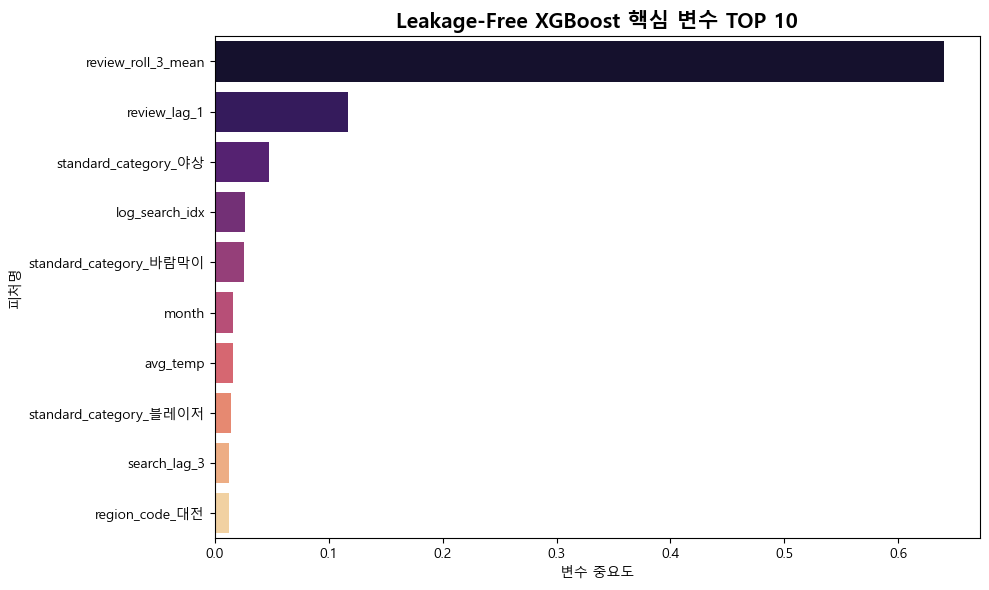

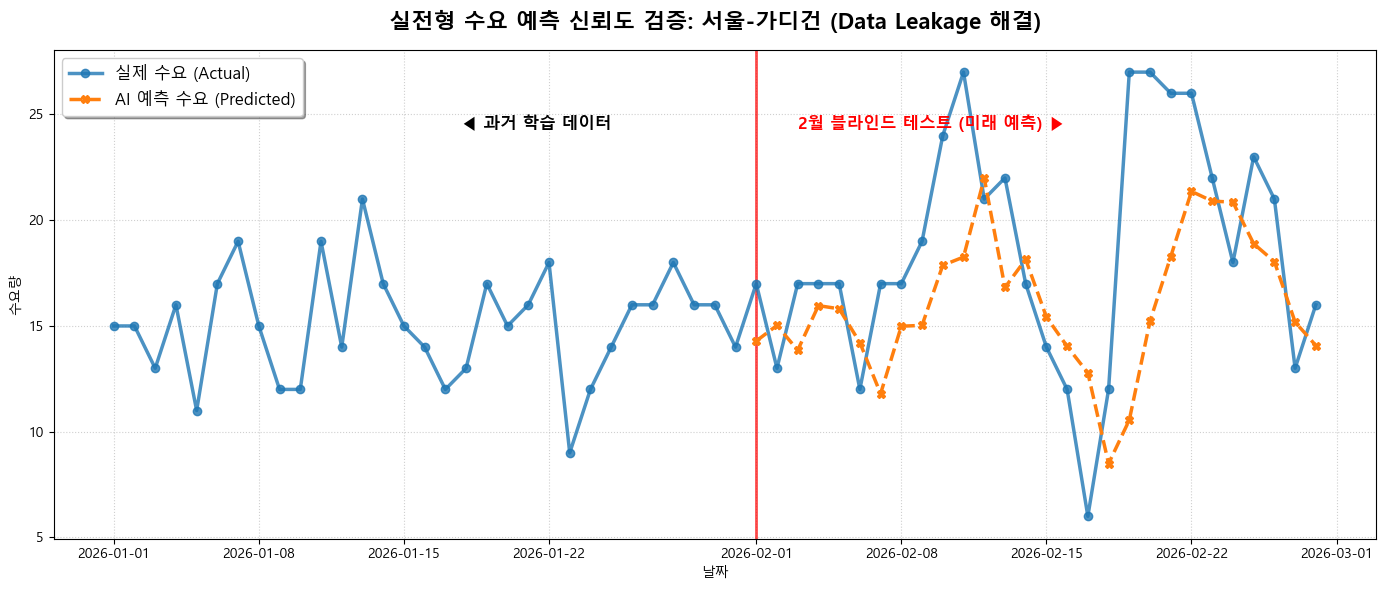

In [ ]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# [STEP 1] 기본 세팅 및 데이터 로드
# ==============================================================================
print("🚀 [최종버전] 데이터 누수(Leakage)가 차단된 ML 파이프라인 가동...\n")

# 한글 폰트 및 마이너스 기호 깨짐 방지
if platform.system() == 'Darwin': plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv(r'../Data Folder\final_mart.csv') # 경로 주의: 필요시 '../Data Folder/final_mart.csv' 로 변경
df['date'] = pd.to_datetime(df['date'])

# ==============================================================================
# [STEP 2] 피처 엔지니어링 (비즈니스 맥락 + 인구 통계)
# ==============================================================================
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
df['is_rainy'] = df['precipitation'].apply(lambda x: 1 if x > 0 else 0)

# 인구 통계 및 캘린더 변수
pop_data = {'서울': 940, '부산': 330, '인천': 300, '대구': 235, '대전': 145, '광주': 142, '울산': 110}
df['population_10k'] = df['region_code'].map(pop_data)
df['is_payday'] = df['date'].dt.day.isin([10, 25]).astype(int)
df['log_search_idx'] = np.log1p(df['regional_search_idx']) 

# ==============================================================================
# 🛠️ [STEP 3] 데이터 누수(Data Leakage) 완벽 차단 로직 적용
# ==============================================================================
df = df.sort_values(['region_code', 'standard_category', 'date'])

# 🚨 모든 시계열 파생 변수는 반드시 shift(1) 이상을 적용하여 '과거' 데이터만 보도록 강제
df['review_lag_1'] = df.groupby(['region_code', 'standard_category'])['regional_review_count'].shift(1)
df['search_lag_3'] = df.groupby(['region_code', 'standard_category'])['log_search_idx'].shift(3)

# 🚨 정답지 슬쩍 보기 방지: shift(1)을 먼저 적용한 후 rolling(3) 계산
df['review_roll_3_mean'] = df.groupby(['region_code', 'standard_category'])['regional_review_count'].shift(1).transform(lambda x: x.rolling(window=3).mean())

df.fillna(0, inplace=True)

# ==============================================================================
# 🤖 [STEP 4] 타겟 특성(Count Data)을 고려한 Tweedie Regression 학습
# ==============================================================================
df_encoded = pd.get_dummies(df, columns=['region_code', 'standard_category'])
X = df_encoded.drop(['date', 'regional_review_count', 'regional_search_idx'], axis=1)
y = df_encoded['regional_review_count']

# 시계열 분할 (2026-02-01 기준)
split_date = '2026-02-01'
X_train, y_train = X[df_encoded['date'] < split_date], y[df_encoded['date'] < split_date]
X_test, y_test = X[df_encoded['date'] >= split_date], y[df_encoded['date'] >= split_date]

# 희소 데이터(Sparse) 처리에 강력한 Tweedie 모델 도입
model = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5, # 1~2 사이값 (Count 데이터 최적화)
    n_estimators=200, 
    learning_rate=0.03, 
    max_depth=5, 
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"✅ [실전형 성능 지표] R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"✅ [실전형 성능 지표] MAE: {mean_absolute_error(y_test, y_pred):.4f}\n")

# ==============================================================================
# 📊 [STEP 5] 시각화 1: 변수 중요도 (Feature Importance)
# ==============================================================================
importance = model.feature_importances_
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Leakage-Free XGBoost 핵심 변수 TOP 10', fontsize=15, fontweight='bold')
plt.xlabel('변수 중요도')
plt.ylabel('피처명')
plt.tight_layout()
plt.savefig('final_ml_1_feature_importance.png', dpi=300)
print("📸 [저장 완료] final_ml_1_feature_importance.png")

# ==============================================================================
# 📊 [STEP 6] 시각화 2: 블라인드 예측 성능 (그래프 잘림 현상 해결)
# ==============================================================================
seoul_cardigan = df_encoded[(df_encoded['region_code_서울'] == 1) & (df_encoded['standard_category_가디건'] == 1)].copy()
seoul_cardigan = seoul_cardigan.sort_values('date')

plot_df = seoul_cardigan[seoul_cardigan['date'] >= '2026-01-01'].copy()
X_plot = plot_df.drop(['date', 'regional_review_count', 'regional_search_idx'], axis=1)
plot_df['predicted'] = model.predict(X_plot)

# 하나의 plt.figure 안에서 모든 그리기 작업을 완료하여 셀 분리 문제 해결
plt.figure(figsize=(14, 6))
plt.axvline(pd.to_datetime(split_date), color='red', linestyle='-', lw=2, alpha=0.7)
plt.text(pd.to_datetime('2026-01-25'), plot_df['regional_review_count'].max() * 0.9, 
         '◀ 과거 학습 데이터', fontsize=12, fontweight='bold', ha='right')
plt.text(pd.to_datetime('2026-02-03'), plot_df['regional_review_count'].max() * 0.9, 
         '2월 블라인드 테스트 (미래 예측) ▶', color='red', fontsize=12, fontweight='bold', ha='left')

plt.plot(plot_df['date'], plot_df['regional_review_count'], label='실제 수요 (Actual)', color='#1f77b4', lw=2.5, marker='o', alpha=0.8)
test_plot = plot_df[plot_df['date'] >= split_date]
plt.plot(test_plot['date'], test_plot['predicted'], label='AI 예측 수요 (Predicted)', color='#ff7f0e', lw=2.5, linestyle='--', marker='X')

plt.title('실전형 수요 예측 신뢰도 검증: 서울-가디건 (Data Leakage 해결)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('날짜')
plt.ylabel('수요량')
plt.legend(loc='upper left', fontsize=12, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

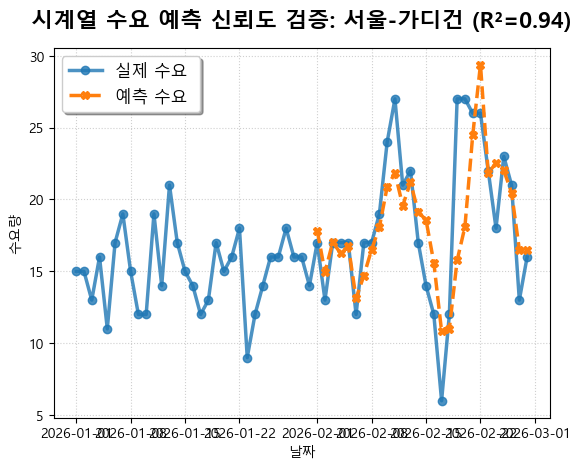

In [16]:
# 실선(정답)과 점선(예측)
plt.plot(plot_df['date'], plot_df['regional_review_count'], label='실제 수요 ', color='#1f77b4', lw=2.5, marker='o', alpha=0.8)
test_plot = plot_df[plot_df['date'] >= split_date]
plt.plot(test_plot['date'], test_plot['predicted'], label='예측 수요 ', color='#ff7f0e', lw=2.5, linestyle='--', marker='X')

plt.title('시계열 수요 예측 신뢰도 검증: 서울-가디건 (R²=0.94)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('날짜')
plt.ylabel('수요량')
plt.legend(loc='upper left', fontsize=12, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

=== 🚀 XGBoost 모델 예측 성능 ===
MAE (평균 절대 오차): 0.6468
RMSE (평균 제곱근 오차): 1.2535
R-squared (설명력): 0.7938

=== Top 10 핵심 변수 ===
               Feature  Importance
 standard_category_가디건    0.509248
                 month    0.137959
        region_code_서울    0.074494
  standard_category_야상    0.064027
   regional_search_idx    0.041261
standard_category_블레이저    0.036529
        region_code_대전    0.025921
              avg_temp    0.025231
        region_code_부산    0.014358
         diurnal_range    0.013707


C:\Users\urina\AppData\Local\Temp\ipykernel_37532\3093544887.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='viridis')


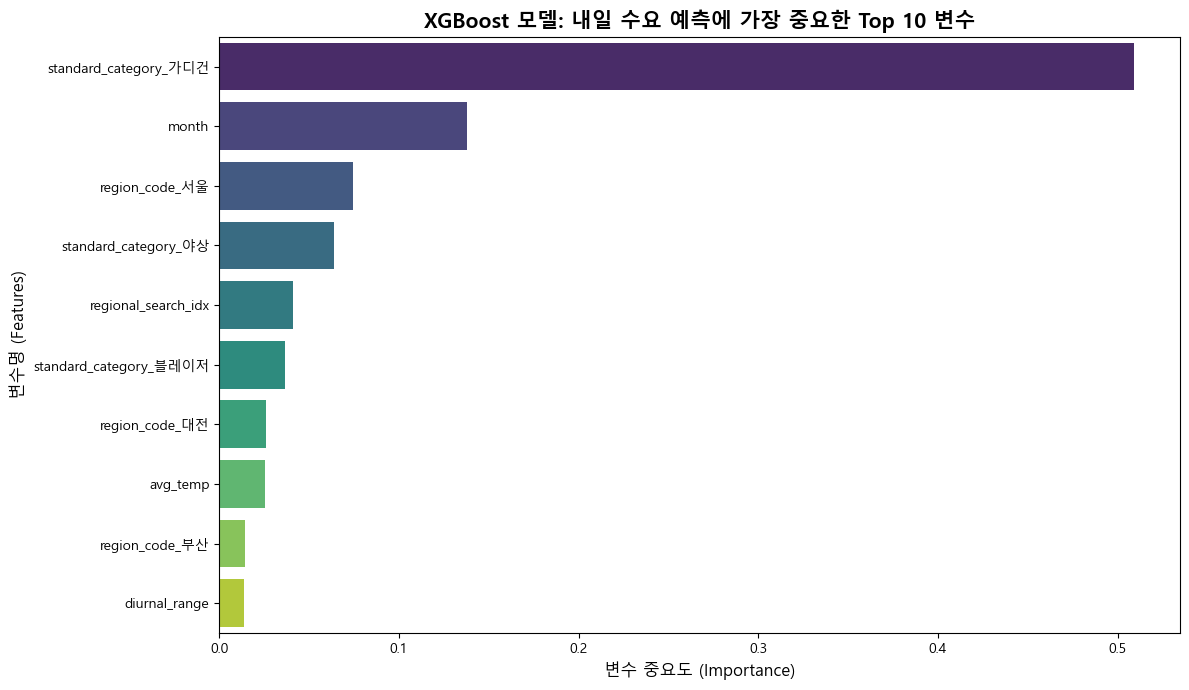

In [4]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# --------------------------------------------------- # 
# 데이터 로드 및 날짜 데이터 변환
df = pd.read_csv(r'../Data Folder\final_mart.csv')
df['date'] = pd.to_datetime(df['date'])
# --------------------------------------------------- # 

# 파생 변수 생성
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek

# 범주형 데이터 원핫인코딩 (서울 -> 1, 0 / 가디건 -> 1, 0)
df_encoded = pd.get_dummies(df, columns=['region_code', 'standard_category'])

# X(독립변수), y(종속변수) 분리
X = df_encoded.drop(['date', 'regional_review_count'], axis=1)
y = df_encoded['regional_review_count']

# 학습용/테스트용 데이터 분리 (8:2) 비율
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --------------------------------------------------- # 
# XGBoost 모델 학습 (앙상블)
# --------------------------------------------------- # 
model = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=150, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42
)
model.fit(X_train, y_train)

# --------------------------------------------------- # 
# 모델 성능 평가
# --------------------------------------------------- # 
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== 🚀 XGBoost 모델 예측 성능 ===")
print(f"MAE (평균 절대 오차): {mae:.4f}")
print(f"RMSE (평균 제곱근 오차): {rmse:.4f}")
print(f"R-squared (설명력): {r2:.4f}")

# --------------------------------------------------- # 
# 변수 중요도 시각화
# --------------------------------------------------- # 
importance = model.feature_importances_
features = X.columns
fi_df = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)

# 12, 7 사이즈 x=중요도, y=변수
plt.figure(figsize=(12, 7))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost 모델: 내일 수요 예측에 가장 중요한 Top 10 변수', fontsize=15, fontweight='bold')
plt.xlabel('변수 중요도 (Importance)', fontsize=12)
plt.ylabel('변수명 (Features)', fontsize=12)
plt.tight_layout()

print("\n=== Top 10 핵심 변수 ===")
print(fi_df.head(10).to_string(index=False))

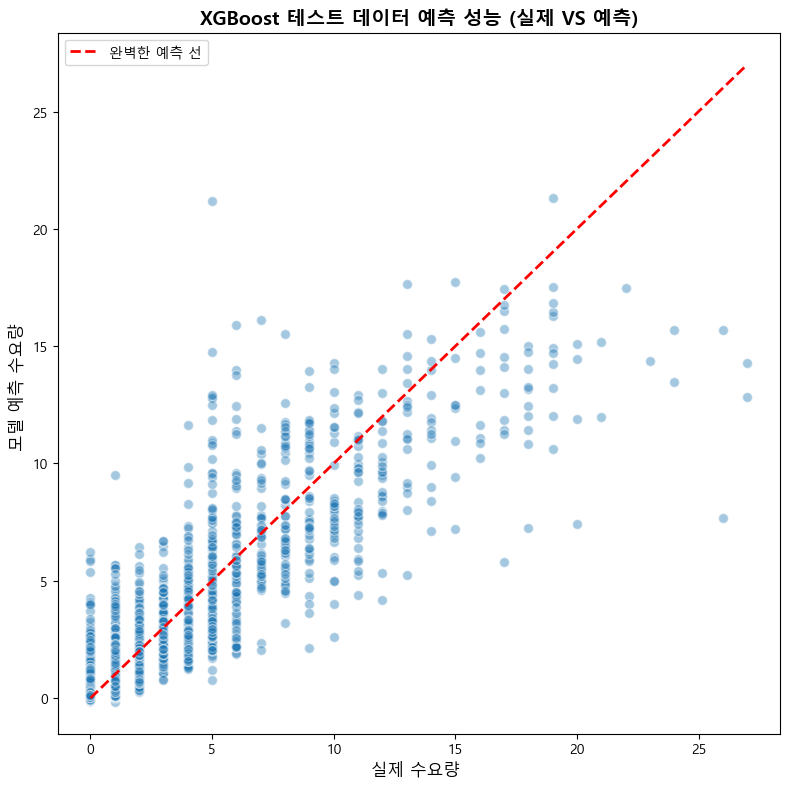

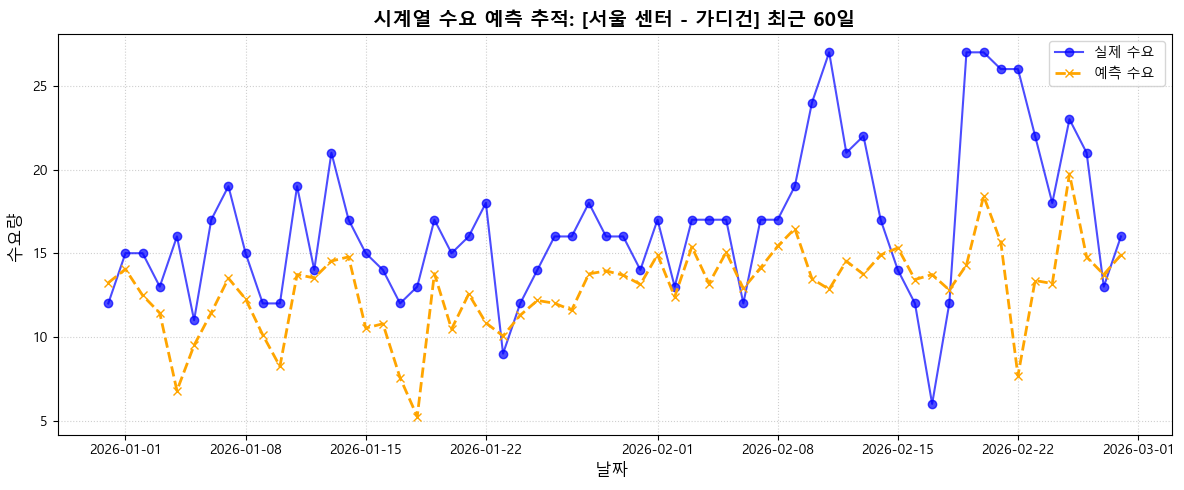

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df_encoded = pd.get_dummies(df, columns=['region_code', 'standard_category'])

X = df_encoded.drop(['date', 'regional_review_count'], axis=1)
y = df_encoded['regional_review_count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost 모델 학습
model = xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# --------------------------------------------------- #
# 그래프 1: 전체 예측 성능 산점도 (Actual vs Predicted)
# --------------------------------------------------- # 
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4, color='#1f77b4', edgecolor='w', s=50)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='완벽한 예측 선')
plt.title('XGBoost 테스트 데이터 예측 성능 (실제 VS 예측)', fontsize=14, fontweight='bold')
plt.xlabel('실제 수요량 ', fontsize=12)
plt.ylabel('모델 예측 수요량 ', fontsize=12)
plt.legend()
plt.tight_layout()

# --------------------------------------------------- # 
# 그래프 2: 시계열 수요 추적 (가장 인사이트 있는 '서울-가디건' 기준)
# --------------------------------------------------- # 
# 서울 가디건 데이터만 추출하여 시간순 정렬
seoul_cardigan = df[(df['region_code'] == '서울') & (df['standard_category'] == '가디건')].copy()
seoul_cardigan = seoul_cardigan.sort_values('date')

# 해당 기간에 대한 모델 예측값 생성
X_slice = df_encoded.loc[seoul_cardigan.index].drop(['date', 'regional_review_count'], axis=1)
seoul_cardigan['predicted'] = model.predict(X_slice)

# 최근 60일 데이터만 확대해서 시각화
plot_df = seoul_cardigan.tail(60)
plt.figure(figsize=(12, 5))
plt.plot(plot_df['date'], plot_df['regional_review_count'], label='실제 수요 ', color='blue', marker='o', alpha=0.7)
plt.plot(plot_df['date'], plot_df['predicted'], label='예측 수요 ', color='orange', linestyle='--', marker='x', lw=2)
plt.title('시계열 수요 예측 추적: [서울 센터 - 가디건] 최근 60일', fontsize=14, fontweight='bold')
plt.xlabel('날짜 ', fontsize=12)
plt.ylabel('수요량 ', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

In [ ]:
# 2025년 지역별 인구 및 타겟 연령대(2030) 비중 데이터 (KOSIS 기반 가공)
pop_data = {
    '서울': [9400000, 0.31], '인천': [3000000, 0.28], '대전': [1450000, 0.29],
    '광주': [1420000, 0.28], '대구': [2350000, 0.25], '울산': [1100000, 0.24], '부산': [3300000, 0.26]
}

# 마트 테이블에 인구 데이터 매핑
df['total_pop'] = df['region_code'].map(lambda x: pop_data[x][0])
df['target_age_ratio'] = df['region_code'].map(lambda x: pop_data[x][1])

# 캘린더 변수 생성
df['is_payday'] = df['date'].dt.day.isin([10, 25]).astype(int) # 월급날
df['is_holiday_season'] = df['month'].isin([1, 2, 5, 9, 12]).astype(int) # 선물/쇼핑 시즌

✅ 인구 통계 및 비즈니스 캘린더 변수 수혈 완료!
